# Assignment2

Anton Laitakari

## Task 0: Course Project Dataset
Task 0a: 
**Dataset:** World Happiness Report 2015  
**Source:** https://www.kaggle.com/datasets/unsdsn/world-happiness

Task 0b:
The dataset contains happiness scores and rankings for 158 countries. Key variables include:
- `Country`, `Region`: country and world region
- `Happiness Score`: overall happiness score
- `Economy (GDP per Capita)`, `Family`, `Health (Life Expectancy)`: contributing factors
- `Freedom`, `Trust (Government Corruption)`, `Generosity`

**Rows:** 158 (one per country)

**Plan:** Explore what factors most influence happiness, compare regions, 
and potentially build a regression model to predict happiness from other variables.

## AI Usage
Claude (claude.ai) was used extensively throughout this assignment to support both the development and debugging of the code required for each task. It assisted in structuring the logic, identifying and resolving errors, and suggesting improvements to ensure the code was efficient and functional. In addition, all outputs generated with the help of Claude were carefully validated against real data sources to ensure accuracy and reliability.

In [1]:
# Task 0c: Load dataset and summary statistics
import pandas as pd

df0 = pd.read_csv("2015.csv")
display(df0.head())
display(df0.describe())

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
mean,79.493671,5.375734,0.047885,0.846137,0.991046,0.630259,0.428615,0.143422,0.237296,2.098977
std,45.754363,1.145010,0.017146,0.403121,0.272369,0.247078,0.150693,0.120034,0.126685,0.553550
min,1.000000,2.839000,0.018480,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.328580
25%,40.250000,4.526000,0.037268,0.545808,0.856823,0.439185,0.328330,0.061675,0.150553,1.759410
50%,79.500000,5.232500,0.043940,0.910245,1.029510,0.696705,0.435515,0.107220,0.216130,2.095415
75%,118.750000,6.243750,0.052300,1.158448,1.214405,0.811013,0.549092,0.180255,0.309883,2.462415
max,158.000000,7.587000,0.136930,1.690420,1.402230,1.025250,0.669730,0.551910,0.795880,3.602140


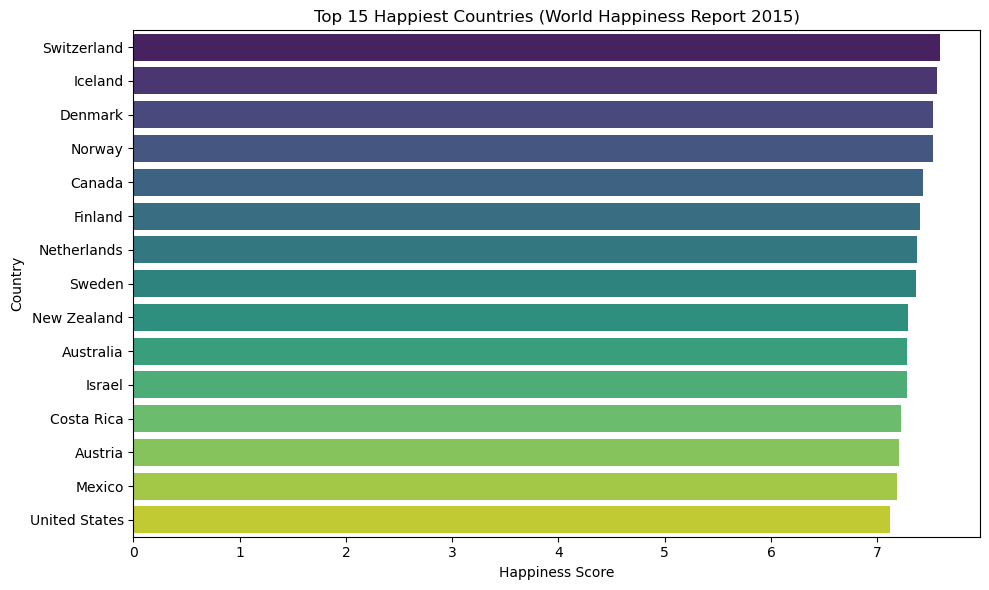

In [2]:
# Task 0c: Visualization 1 - Top 15 happiest countries
import matplotlib.pyplot as plt
import seaborn as sns

top15 = df0.nlargest(15, "Happiness Score")

plt.figure(figsize=(10, 6))
sns.barplot(data=top15, x="Happiness Score", y="Country", palette="viridis")
plt.title("Top 15 Happiest Countries (World Happiness Report 2015)")
plt.xlabel("Happiness Score")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

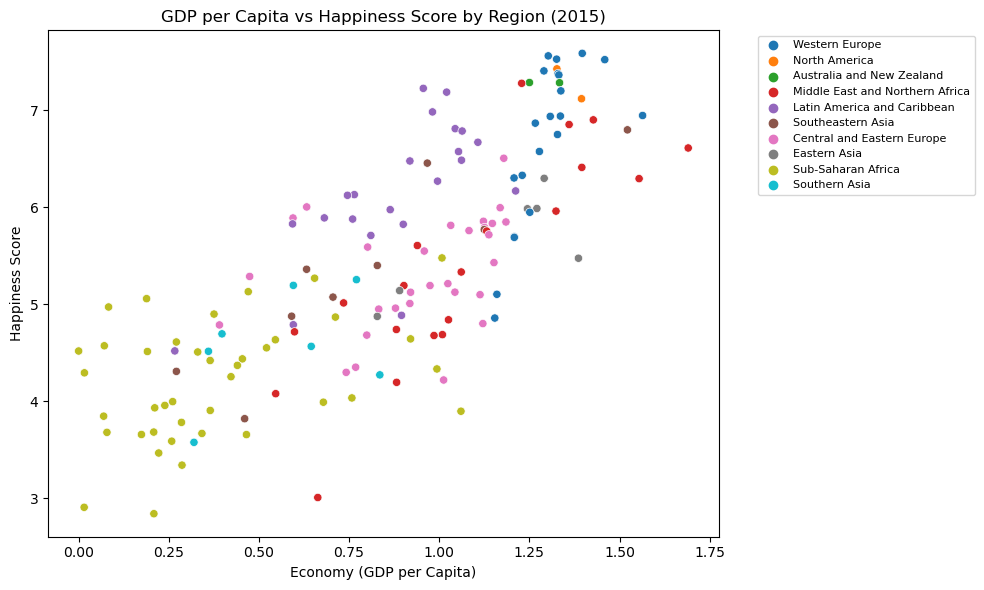

In [3]:
# Task 0c: Visualization 2 - GDP per Capita vs Happiness Score, colored by Region
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df0, x="Economy (GDP per Capita)", y="Happiness Score",
                hue="Region", palette="tab10")
plt.title("GDP per Capita vs Happiness Score by Region (2015)")
plt.xlabel("Economy (GDP per Capita)")
plt.ylabel("Happiness Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## Task1 Setting up an API key and .env file

In [10]:
from dotenv import load_dotenv
import os

load_dotenv()
api_key = os.getenv("MARKETSTACK_API_KEY")

if api_key is None:
    raise ValueError("Key not found!")

print(api_key[:5] + "...")

9d40c...


## Task2 Retrieving data from MarketStack 

In [12]:
# Task 2a: Retrieve FAANG EOD data for March 2026
import requests
import pandas as pd

tickers = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]
all_data = []

for ticker in tickers:
    response = requests.get(
        "http://api.marketstack.com/v1/eod",
        params={
            "access_key": api_key,
            "symbols": ticker,
            "date_from": "2026-03-01",
            "date_to": "2026-03-31",
            "limit": 50,
        }
    )
    data = response.json()
    all_data.extend(data["data"])

# Task 2b: Convert to DataFrame
df = pd.DataFrame(all_data)
df["date"] = pd.to_datetime(df["date"]).dt.date
df = df.sort_values(["symbol", "date"]).reset_index(drop=True)
display(df.head())

,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,262.440,266.530,260.20,264.72,41576035.0,266.530,260.20,264.72,262.41,41827946.0,1.0,0.0,AAPL,XNAS,2026-03-02
1,263.480,265.560,260.13,263.75,37994695.0,265.560,260.13,263.75,263.48,38568921.0,1.0,0.0,AAPL,XNAS,2026-03-03
2,264.650,266.150,261.42,262.52,39258957.0,266.150,261.42,262.52,264.65,39803119.0,1.0,0.0,AAPL,XNAS,2026-03-04
3,260.745,261.555,257.25,260.29,49424671.0,261.555,257.25,260.29,260.79,49658626.0,1.0,0.0,AAPL,XNAS,2026-03-05
4,258.740,258.760,254.37,257.46,40628988.0,258.770,254.37,257.46,258.63,41120042.0,1.0,0.0,AAPL,XNAS,2026-03-06


In [13]:
# Task 2c: Summary statistics and monthly return per stock
summary = df.groupby("symbol")["close"].describe()
display(summary)

# Calculate return % from first to last trading day
returns = (
    df.groupby("symbol")
    .apply(lambda g: (g.sort_values("date").iloc[-1]["close"] /
                      g.sort_values("date").iloc[0]["close"] - 1) * 100)
    .rename("return_pct")
    .reset_index()
)
display(returns)

best = returns.loc[returns["return_pct"].idxmax(), "symbol"]
worst = returns.loc[returns["return_pct"].idxmin(), "symbol"]
print(f"Best performer in March 2026: {best}")
print(f"Worst performer in March 2026: {worst}")

,count,mean,std,min,25%,50%,75%,max
symbol,,,,,,,,
AAPL,22.0,254.906364,5.510351,246.63,250.4625,253.340,260.1875,264.72
AMZN,22.0,209.995000,4.643217,199.34,207.8200,209.700,213.0700,218.94
GOOG,22.0,297.980455,10.928636,273.14,291.7675,302.335,305.9400,309.41
META,22.0,614.990909,41.309579,525.72,593.9675,619.170,652.0175,667.73
NFLX,22.0,95.076364,2.512109,90.92,93.3350,94.795,97.0525,99.17


,symbol,return_pct
0,AAPL,-4.128891
1,AMZN,-0.057584
2,GOOG,-6.365061
3,META,-12.459453
4,NFLX,-0.968174


Best performer in March 2026: AMZN
Worst performer in March 2026: META


## Task3 Visualizing stock data 

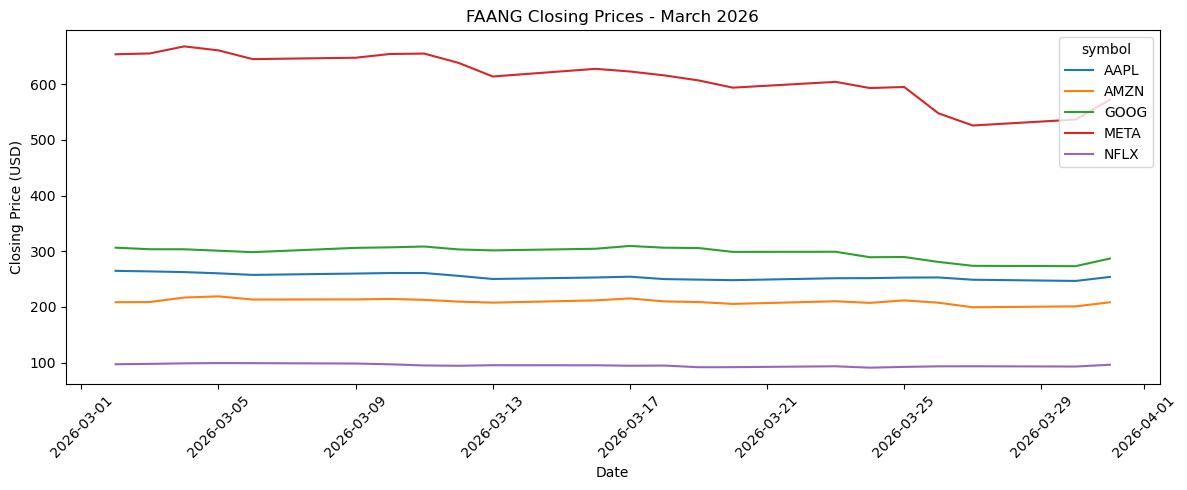

In [14]:
# Task 3: Visualizations with seaborn
import seaborn as sns
import matplotlib.pyplot as plt

# 3a: Line chart of closing prices over time
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x="date", y="close", hue="symbol")
plt.title("FAANG Closing Prices - March 2026")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

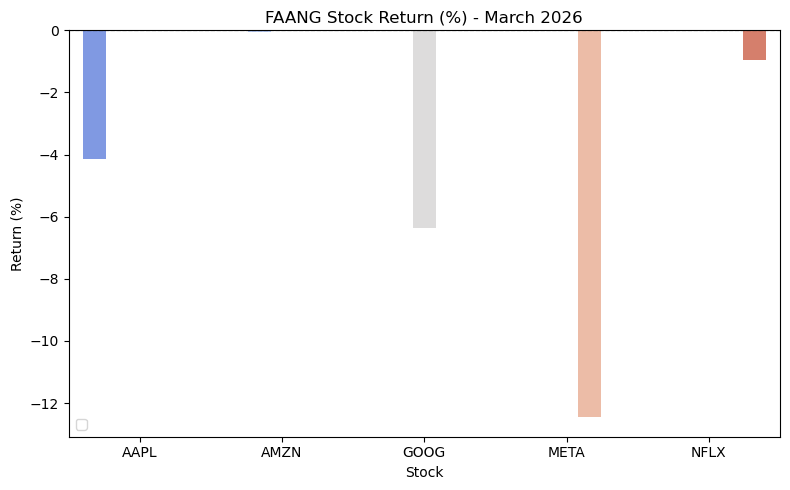

In [23]:
# Task 3b: Bar plot of monthly return percentage
plt.figure(figsize=(8, 5))
sns.barplot(data=returns, x="symbol", y="return_pct", hue="symbol", palette="coolwarm")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("FAANG Stock Return (%) - March 2026")
plt.xlabel("Stock")
plt.ylabel("Return (%)")
plt.legend([])  # hides the legend for older seaborn versions
plt.tight_layout()
plt.show()

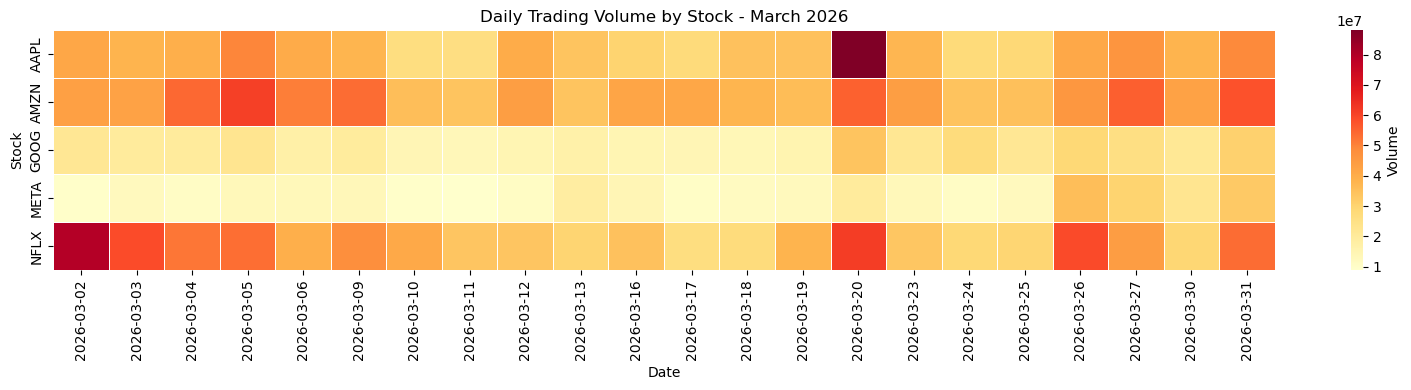

In [16]:
# 3c: Heatmap of daily trading volume
volume_pivot = df.pivot(index="symbol", columns="date", values="volume")

plt.figure(figsize=(16, 4))
sns.heatmap(volume_pivot, cmap="YlOrRd", linewidths=0.5,
            cbar_kws={"label": "Volume"})
plt.title("Daily Trading Volume by Stock - March 2026")
plt.xlabel("Date")
plt.ylabel("Stock")
plt.tight_layout()
plt.show()

## Task4 Exporting and importing data

In [17]:
# Task 4a & 4b: Export JSON and CSV
import json
import os

os.makedirs("exports", exist_ok=True)

# Export original JSON
with open("exports/stockdata.json", "w") as f:
    json.dump(all_data, f)

# Export DataFrame as CSV
df.to_csv("exports/stockdata.csv", index=False)

print("Files exported successfully.")

Files exported successfully.


In [19]:
# Task 4c: Load back and verify
with open("exports/stockdata.json", "r") as f:
    loaded_json = json.load(f)

df_from_json = pd.DataFrame(loaded_json)
print("From JSON:")
display(df_from_json.head())

df_from_csv = pd.read_csv("exports/stockdata.csv")
print("From CSV:")
display(df_from_csv.head())

From JSON:


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,549.98,573.69,546.77,572.13,32809500.0,573.6900,546.77,572.13,549.98,32898272.0,1.0,0.0,META,ARCX,2026-03-31T00:00:00+0000
1,536.38,539.55,528.54,536.38,22758800.0,539.5500,528.54,536.38,536.38,22795203.0,1.0,0.0,META,ARCX,2026-03-30T00:00:00+0000
2,540.10,543.60,520.26,525.72,29980300.0,543.5999,520.26,525.72,540.10,30133010.0,1.0,0.0,META,ARCX,2026-03-27T00:00:00+0000
3,582.49,583.00,543.35,547.54,35664700.0,583.0000,543.35,547.54,582.49,35780131.0,1.0,0.0,META,ARCX,2026-03-26T00:00:00+0000
4,598.74,603.62,593.40,594.89,12161179.0,603.6700,593.40,594.89,598.74,12585031.0,1.0,0.0,META,ARCX,2026-03-25T00:00:00+0000


From CSV:


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,262.440,266.530,260.20,264.72,41576035.0,266.530,260.20,264.72,262.41,41827946.0,1.0,0.0,AAPL,XNAS,2026-03-02
1,263.480,265.560,260.13,263.75,37994695.0,265.560,260.13,263.75,263.48,38568921.0,1.0,0.0,AAPL,XNAS,2026-03-03
2,264.650,266.150,261.42,262.52,39258957.0,266.150,261.42,262.52,264.65,39803119.0,1.0,0.0,AAPL,XNAS,2026-03-04
3,260.745,261.555,257.25,260.29,49424671.0,261.555,257.25,260.29,260.79,49658626.0,1.0,0.0,AAPL,XNAS,2026-03-05
4,258.740,258.760,254.37,257.46,40628988.0,258.770,254.37,257.46,258.63,41120042.0,1.0,0.0,AAPL,XNAS,2026-03-06


## Task5 Querying the Northwind database

In [27]:
# Task 5a: Connect and list tables
import sqlite3

conn = sqlite3.connect("Northwind.db")
cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = [row[0] for row in cursor.fetchall()]
print("Tables in database:", tables)

Tables in database: ['Categories', 'sqlite_sequence', 'CustomerCustomerDemo', 'CustomerDemographics', 'Customers', 'Employees', 'EmployeeTerritories', 'Order Details', 'Orders', 'Products', 'Regions', 'Shippers', 'Suppliers', 'Territories']


In [28]:
# Task 5b: Products with UnitPrice > 30
query_5b = """
SELECT ProductName, UnitPrice, UnitsInStock
FROM Products
WHERE UnitPrice > 30
"""
df_5b = pd.read_sql_query(query_5b, conn)
display(df_5b)

,ProductName,UnitPrice,UnitsInStock
0,Northwoods Cranberry Sauce,40.00,6
1,Mishi Kobe Niku,97.00,29
2,Ikura,31.00,31
3,Queso Manchego La Pastora,38.00,86
4,Alice Mutton,39.00,0
5,Carnarvon Tigers,62.50,42
6,Sir Rodney's Marmalade,81.00,40
7,Gumbär Gummibärchen,31.23,15
8,Schoggi Schokolade,43.90,49
9,Rössle Sauerkraut,45.60,26


In [29]:
# Task 5c: Orders shipped to Germany with line totals
query_5c = """
SELECT c.CompanyName,
       o.OrderID,
       o.OrderDate,
       o.ShipCountry,
       od.UnitPrice * od.Quantity AS LineTotal
FROM Orders o
JOIN Customers c ON o.CustomerID = c.CustomerID
JOIN 'Order Details' od ON o.OrderID = od.OrderID
WHERE o.ShipCountry = 'Germany'
"""
df_5c = pd.read_sql_query(query_5c, conn)
display(df_5c)

,CompanyName,OrderID,OrderDate,ShipCountry,LineTotal
0,Toms Spezialitäten,10249,2016-07-05,Germany,167.4
1,Toms Spezialitäten,10249,2016-07-05,Germany,1696.0
2,Ottilies Käseladen,10260,2016-07-19,Germany,123.2
3,Ottilies Käseladen,10260,2016-07-19,Germany,780.0
4,Ottilies Käseladen,10260,2016-07-19,Germany,591.0
...,...,...,...,...,...
80668,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,864.0
80669,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,735.0
80670,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,75.0
80671,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,500.0


## Task6 Visualizing Northwind data

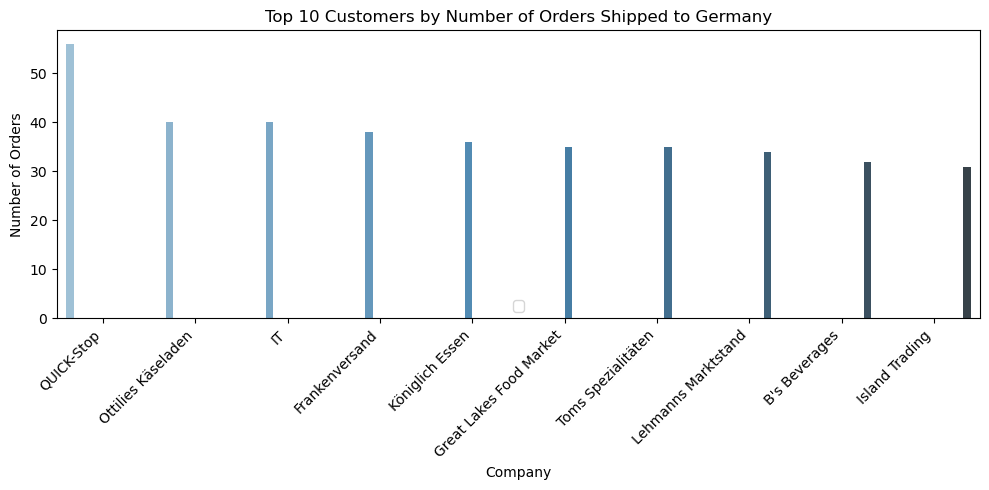

In [31]:
# Task 6a: Bar plot - orders per customer (top 10, Germany)
orders_per_customer = (
    df_5c.groupby("CompanyName")["OrderID"]
    .nunique()
    .reset_index()
    .rename(columns={"OrderID": "num_orders"})
    .sort_values("num_orders", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=orders_per_customer, x="CompanyName", y="num_orders",
            hue="CompanyName", palette="Blues_d")
plt.title("Top 10 Customers by Number of Orders Shipped to Germany")
plt.xlabel("Company")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45, ha="right")
plt.legend([])
plt.tight_layout()
plt.show()

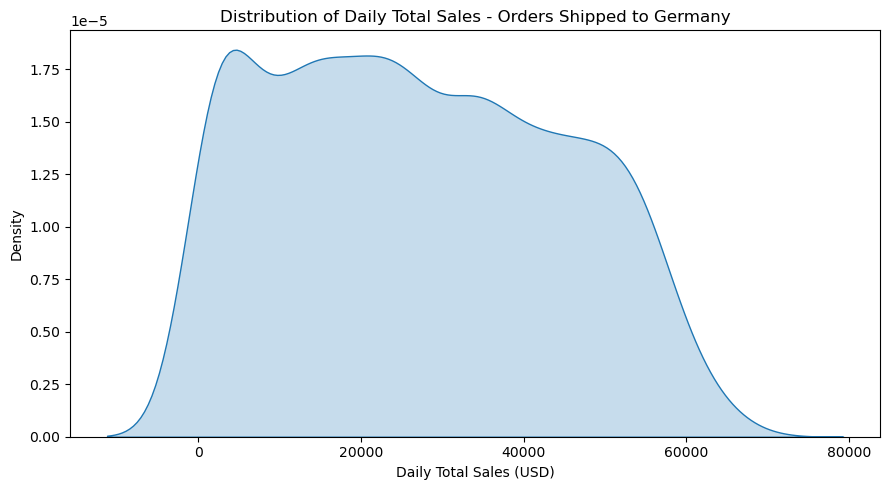

In [33]:
# Task 6b: KDE plot of daily total sales for Germany orders
df_5c["OrderDate"] = pd.to_datetime(df_5c["OrderDate"], format="mixed")
daily_sales = df_5c.groupby("OrderDate")["LineTotal"].sum().reset_index()

plt.figure(figsize=(9, 5))
sns.kdeplot(data=daily_sales, x="LineTotal", fill=True)
plt.title("Distribution of Daily Total Sales - Orders Shipped to Germany")
plt.xlabel("Daily Total Sales (USD)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

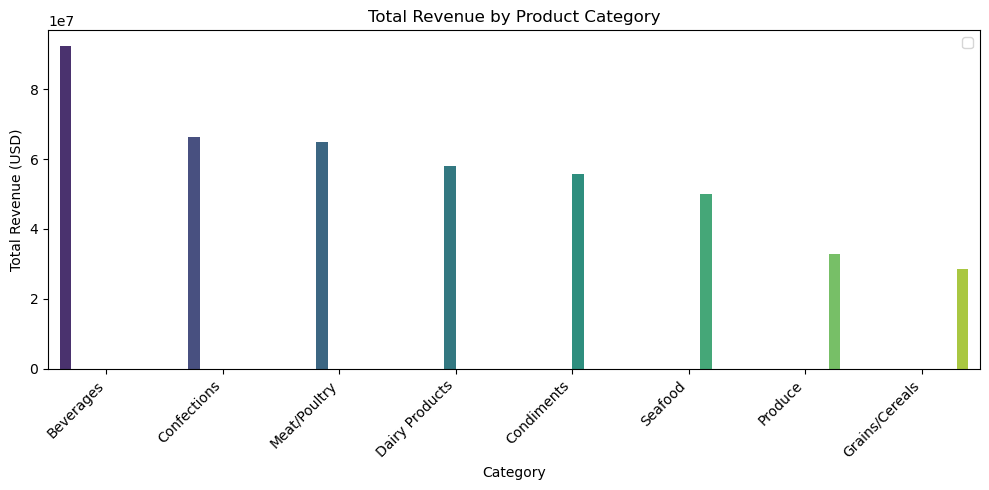

In [34]:
# Task 6c: Total revenue per product category
query_6c = """
SELECT cat.CategoryName,
       SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM 'Order Details' od
JOIN Products p ON od.ProductID = p.ProductID
JOIN Categories cat ON p.CategoryID = cat.CategoryID
GROUP BY cat.CategoryName
"""
df_6c = pd.read_sql_query(query_6c, conn)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_6c.sort_values("TotalRevenue", ascending=False),
            x="CategoryName", y="TotalRevenue",
            hue="CategoryName", palette="viridis")
plt.title("Total Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue (USD)")
plt.xticks(rotation=45, ha="right")
plt.legend([])
plt.tight_layout()
plt.show()

## Task7 Comparing Python to SQL

In [35]:
# Task 7a: Load Products and Categories tables fully
df_products = pd.read_sql_query("SELECT * FROM Products", conn)
df_categories = pd.read_sql_query("SELECT * FROM Categories", conn)

display(df_products.head())
display(df_categories.head())

,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1


,CategoryID,CategoryName,Description,Picture
0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Confections,"Desserts, candies, and sweet breads",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Dairy Products,Cheeses,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Grains/Cereals,"Breads, crackers, pasta, and cereal",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


In [36]:
# Task 7b: Inner join with pandas
df_joined = df_products.merge(df_categories, on="CategoryID", how="inner")
display(df_joined.head())

,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued,CategoryName,Description,Picture
0,1,Chai,1,1,10 boxes x 20 bags,18.0,39,0,10,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Chang,1,1,24 - 12 oz bottles,19.0,17,40,25,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,24,Guaraná Fantástica,10,1,12 - 355 ml cans,4.5,20,0,0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,34,Sasquatch Ale,16,1,24 - 12 oz bottles,14.0,111,0,15,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,35,Steeleye Stout,16,1,24 - 12 oz bottles,18.0,20,0,15,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


In [37]:
# Task 7c: Speed comparison
import time

# SQL approach (from Task 6c)
start_sql = time.time()
df_sql_result = pd.read_sql_query(query_6c, conn)
end_sql = time.time()
sql_time = end_sql - start_sql

# Pandas approach
start_pandas = time.time()
df_od = pd.read_sql_query("SELECT * FROM 'Order Details'", conn)
df_p  = pd.read_sql_query("SELECT * FROM Products", conn)
df_c  = pd.read_sql_query("SELECT * FROM Categories", conn)

df_merged = df_od.merge(df_p[["ProductID", "CategoryID"]], on="ProductID")
df_merged = df_merged.merge(df_c[["CategoryID", "CategoryName"]], on="CategoryID")
df_pandas_result = (
    df_merged.assign(Revenue=df_merged["UnitPrice"] * df_merged["Quantity"])
    .groupby("CategoryName")["Revenue"].sum()
    .reset_index()
)
end_pandas = time.time()
pandas_time = end_pandas - start_pandas

print(f"SQL execution time:    {sql_time:.4f} seconds")
print(f"Pandas execution time: {pandas_time:.4f} seconds")
print("\nComment: SQL is typically faster for aggregations since the database engine")
print("handles grouping natively, whereas pandas loads all raw data into memory first.")

SQL execution time:    0.9907 seconds
Pandas execution time: 1.8457 seconds

Comment: SQL is typically faster for aggregations since the database engine
handles grouping natively, whereas pandas loads all raw data into memory first.


## Task8 Wide and long format 

In [6]:
# Task 8: Setup data
import pandas as pd

wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})

long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})

In [7]:
# Task 8a: Wide -> Long
print("Before (wide):")
display(wide_data)

wide_to_long = pd.melt(wide_data, id_vars=["store"],
                        var_name="quarter", value_name="sales")
print("After (long):")
display(wide_to_long)

Before (wide):


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


After (long):


,store,quarter,sales
0,Helsinki,Q1_sales,12000
1,Tampere,Q1_sales,8500
2,Turku,Q1_sales,9200
3,Helsinki,Q2_sales,13500
4,Tampere,Q2_sales,9100
5,Turku,Q2_sales,9800
6,Helsinki,Q3_sales,11800
7,Tampere,Q3_sales,8800
8,Turku,Q3_sales,10100
9,Helsinki,Q4_sales,15000


In [8]:
# Task 8b: Long -> Wide
print("Before (long):")
display(long_data)

long_to_wide = long_data.pivot(index="month", columns="product", values="units_sold").reset_index()
long_to_wide.columns.name = None
print("After (wide):")
display(long_to_wide)

Before (long):


,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130


After (wide):


,month,Laptop,Phone
0,Feb,50,110
1,Jan,45,120
2,Mar,55,130


In [9]:
# Task 8c: Convert back to originals

# --- Restore wide_data ---
print("Before (long format / transformed):")
display(wide_to_long)  # show the transformed version first

restored_wide = wide_to_long.pivot(index="store", columns="quarter", values="sales").reset_index()
restored_wide.columns.name = None
restored_wide = restored_wide[["store", "Q1_sales", "Q2_sales", "Q3_sales", "Q4_sales"]]
print("After (restored to original wide format):")
display(restored_wide)

# --- Restore long_data ---
print("Before (wide format / transformed):")
display(long_to_wide)  # show the transformed version first

restored_long = pd.melt(long_to_wide, id_vars=["month"],
                         var_name="product", value_name="units_sold")
restored_long = restored_long.sort_values(["month", "product"]).reset_index(drop=True)
print("After (restored to original long format):")
display(restored_long)

Before (long format / transformed):


,store,quarter,sales
0,Helsinki,Q1_sales,12000
1,Tampere,Q1_sales,8500
2,Turku,Q1_sales,9200
3,Helsinki,Q2_sales,13500
4,Tampere,Q2_sales,9100
5,Turku,Q2_sales,9800
6,Helsinki,Q3_sales,11800
7,Tampere,Q3_sales,8800
8,Turku,Q3_sales,10100
9,Helsinki,Q4_sales,15000


After (restored to original wide format):


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


Before (wide format / transformed):


,month,Laptop,Phone
0,Feb,50,110
1,Jan,45,120
2,Mar,55,130


After (restored to original long format):


,month,product,units_sold
0,Feb,Laptop,50
1,Feb,Phone,110
2,Jan,Laptop,45
3,Jan,Phone,120
4,Mar,Laptop,55
5,Mar,Phone,130
